In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Entendimento do negócio

Nessa primeira etapa, queremos exercitar o seu
pensamento analítico, não código. Nos traga a resposta para as seguintes
perguntas de negócio:
- Qual problema de negócio está sendo resolvido?
  - R = empresa cresceu, demanda cresceu, e houve problemas no nps, mas talvez não seja somente questões operacionais e sim com o segmento de clientes.

- Por que o NPS é importante para um e-commerce?
  - R = variavel de saída que resume a experiencia do cliente e define sua relação com a marca, [marketing] sendo um divulgador positivo da marca (promotor) ou um possível churn ou divulgador negativo (detrator). [interna operacional] quais serviços ou departamentos estão com problemas. [e-commerce] reflexo no market share.


- Quais áreas poderiam se beneficiar desses insights? Exemplos:
logística, atendimento, pricing, produto etc.
  - R = suporte e atendimento ao cliente, logística (melhoria de entrega, tempo de entrega, etc), princing/descontos em preços de produtos, marketing na segmentação de clientes e criação de campanhas específicas e mais acertivas.

Além do entendimento do negócio, inclua uma reflexão (não precisa de dados
externos obrigatórios):

### Como o NPS impacta:
- Recompra; - altos nps => melhor experiencia => mais compras do mesmo cliente
- Boca a boca; - promotor (fala bem da empresa, mais indicações orgânicas) vs. detrator (fala mal da empresa, indica compra em concorrentes)
- Market share em e-commerce. - efeito multiplicador de boas experiencias (nps) maior parcela do market share.

Quais indicadores de mercado poderiam complementar essa análise?
Exemplos: benchmarks de NPS, SLA logístico, concorrência.
Pesquisar mais, quais outras métricas utilizadas pelos e-commerces.

# 2. Definição da Target


Qual é o alvo desse problema de negócio? Nessa segunda etapa queremos uma avaliação de entendimento conceitual, não técnico.

- Qual variável representa a satisfação do cliente?
  - R = nps
- Por que ela foi escolhida?
  - R = é a pontuação definida pelo próprio cliente ao final de uma experiência
- Em que momento da jornada essa informação é coletada?
  - R = final da exepriência
- Existe algum risco de usar essa variável de forma inadequada?
  - R = que é um problema pontual e não encontra a real causa de um problema, correlacionar a um setor específico por exemplo atendimento.

# 3. Análise Exploratória dos Dados (EDA)


**Realize uma análise exploratória com foco em negócio, não só estatística. Responda:**
- Quais fatores parecem mais críticos para a satisfação?
- O que mais gera detratores?
- Existe algum “ponto de ruptura” na experiência do cliente?
- Que tipo de cliente tende a ter NPS mais alto ou mais baixo?
Imagine que você está explicando isso para um(a) gerente de operações
que não entende estatística.

## Verificação das características e integridade do dataset

In [14]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/5274d2dac848ed75f15c49fc1885352bc5dcfd46/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv')
df.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


In [15]:
df.tail(7)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
2493,2494,52,Nordeste,12,52494,73.61,2,16.07,7,12,0,36.42,2,1,5,8.5,1,3,6.1
2494,2495,66,Norte,91,52495,345.83,1,9.27,1,14,6,54.81,3,0,8,4.6,0,3,0.0
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7
2499,2500,35,Nordeste,109,52500,420.94,1,16.51,4,11,1,34.16,3,1,0,10.0,1,2,7.6


In [16]:
# from google.colab import drive
# drive.mount('/content/drive')

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [18]:
df.isnull().sum()

,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


A visualização primária das características do dataset nos apresenta 19 variáveis expressas em 2500 casos. Dessas variáveis, temos a seguinte classificação:
- qualitativas nominais:
  - custom_id, order_id,customer_region, repeat_purchase_30d
- quantitativas discretas
  - customer_age, customer_tenure_months, items_quantity, payment_installments, delivery_time_days, delivery_delay_days, delivery_attempts, customer_service_contacts, resolution_time_days, complaints_count,
- quantitativas contínuas
  - order_value, discount_value, freight_value, nps_score, csat_internal_score  

Essa abordagem irá facilitar nossa análise posterior, visto que cada tipo de variável suscita uma forma diferente de abordagem na análise exploratória

## Agrupamentos de dados

As variáveis analisadas podem ser agrupadas em subconjuntos que no futuro nos ajudarão na interpretação dos dados e no reconhecimento de padrões

**Dados do cliente**:
- customer_id (id do cliente)
- customer_age (idade do cliente)
- customer_region (região geográfica do cliente)
- customer_tenure_months (tempo de relacionamento do cliente com a empresa, em meses)

**Dados da encomenda**:
- order_id (id da encomenda)
- order_value (valor da encomenda)
- items_quantity (quantidade de itens)
- discount_value (valor do desconto)
- payment_installments (número de parcelas)

**Dados logísticos:**
- delivery_time_days (tempo de entrega em dias)
- delivery_delay_days (dias de atraso)
- freight_values (valor do frete)
- delivery_attempts (tentativas de entrega)

**Dados de atendimento:**
- customer_service_contacts (contatos do cliente com o atendimento)
- resolution_time_days (tempo de resolução em dias)
- complaints_count (número de reclamações)

**Dados de satisfação:**
- repeat_purchase_30d (recompra dentro de 30 dias)
- nps_score (satisfação do cliente NPS)
- csat_internal_score (Score interno de satisfação)

In [19]:
df.describe(include='all')

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
unique,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Sul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1250.50000,43.396000,NaN,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,NaN,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,NaN,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,NaN,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,NaN,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,NaN,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000


In [91]:
df['nps_score'].describe(include='all')

,nps_score
count,2500.000000
mean,4.378600
std,2.510229
min,0.000000
25%,2.600000
50%,4.400000
75%,6.100000
max,10.000000


## Análise de dados de uma variável

In [20]:
df.groupby('customer_region')['nps_score'].mean().sort_values(ascending=False)

,nps_score
customer_region,
Sul,4.490979
Nordeste,4.421649
Norte,4.382609
Sudeste,4.373846
Centro-Oeste,4.209829


In [21]:
df.groupby('customer_id')['order_id'].count().sort_values(ascending=True)

,order_id
customer_id,
2496,1
2495,1
2494,1
2493,1
2492,1
...,...
17,1
2498,1
2499,1


<Axes: xlabel='customer_region'>

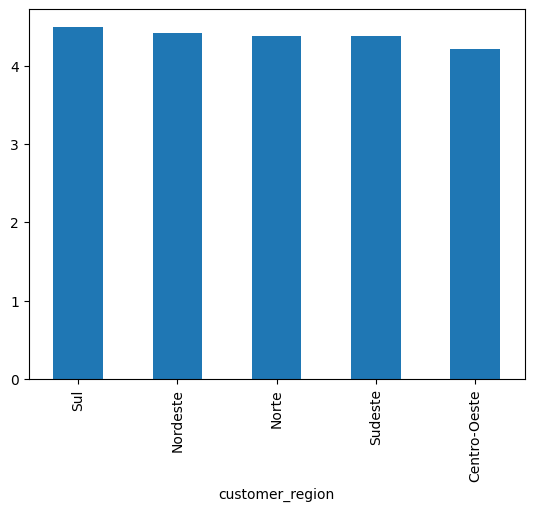

In [22]:
df.groupby('customer_region')['nps_score'].mean().sort_values(ascending=False).plot(kind='bar', x='customer_region', y='nps_score')

Comparando as variaveis do NPS por região, concluíse apenas que em todas as regiões a nota é baixa, porém existe um equilibrio, variando pouco entre uma ou outra região.

In [23]:
df.groupby('customer_region')['nps_score'].std().sort_values(ascending=False)

,nps_score
customer_region,
Centro-Oeste,2.625968
Sul,2.516739
Sudeste,2.491552
Norte,2.485931
Nordeste,2.434829


<Axes: >

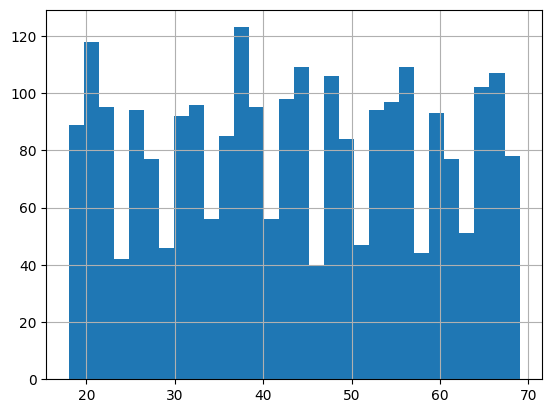

In [24]:
df['customer_age'].hist(bins=30)

In [25]:
def calcula_faixa_etaria(age):
  if age < 21:
    return '[0-20]'
  if age < 41:
    return '[21-40]'
  if age < 61:
    return '[41-60]'
  return '[61-100]'


df['faixa_etaria'] = df['customer_age'].map(calcula_faixa_etaria)

In [26]:
df.head(10)[['customer_age', 'faixa_etaria']]

,customer_age,faixa_etaria
0,63,[61-100]
1,20,[0-20]
2,46,[41-60]
3,52,[41-60]
4,56,[41-60]
5,35,[21-40]
6,37,[21-40]
7,60,[41-60]
8,40,[21-40]
9,51,[41-60]


In [27]:
dataframe_aux = df.groupby('faixa_etaria')['nps_score'].mean()
dataframe_aux

,nps_score
faixa_etaria,
[0-20],4.267320
[21-40],4.400524
[41-60],4.296008
[61-100],4.563614


<Axes: xlabel='faixa_etaria'>

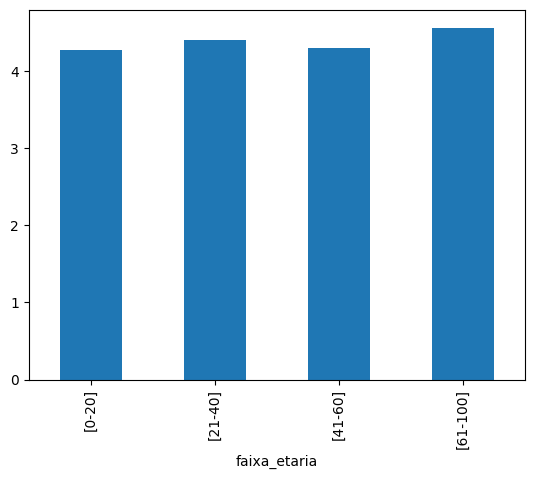

In [28]:
dataframe_aux.plot(kind='bar', x='faixa_etaria', y='nps_score')

In [29]:
dataframe_aux2 = df.groupby(['faixa_etaria', 'customer_region'])['nps_score'].mean().sort_values(ascending=False)
dataframe_aux2

faixa_etaria  customer_region
[61-100]      Sul                5.046914
              Sudeste            4.764444
[0-20]        Sul                4.583333
[21-40]       Nordeste           4.582609
              Norte              4.442365
              Sudeste            4.427317
[41-60]       Sul                4.422170
[61-100]      Norte              4.395402
[0-20]        Sudeste            4.382051
[41-60]       Nordeste           4.369388
[61-100]      Nordeste           4.332099
[41-60]       Norte              4.325131
[21-40]       Sul                4.323232
[0-20]        Norte              4.292000
[61-100]      Centro-Oeste       4.250000
[41-60]       Centro-Oeste       4.219271
[21-40]       Centro-Oeste       4.205455
[41-60]       Sudeste            4.124194
[0-20]        Centro-Oeste       4.091429
              Nordeste           3.916667
Name: nps_score, dtype: float64

In [30]:
dataframe_aux2.index = dataframe_aux2.index.map(lambda x: f"{x[0]}_{x[1]}")

In [31]:
dataframe_aux2.index.name = 'faixa_etaria_regiao'
dataframe_aux2

,nps_score
faixa_etaria_regiao,
[61-100]_Sul,5.046914
[61-100]_Sudeste,4.764444
[0-20]_Sul,4.583333
[21-40]_Nordeste,4.582609
[21-40]_Norte,4.442365
[21-40]_Sudeste,4.427317
[41-60]_Sul,4.422170
[61-100]_Norte,4.395402
[0-20]_Sudeste,4.382051


<Axes: xlabel='faixa_etaria_regiao'>

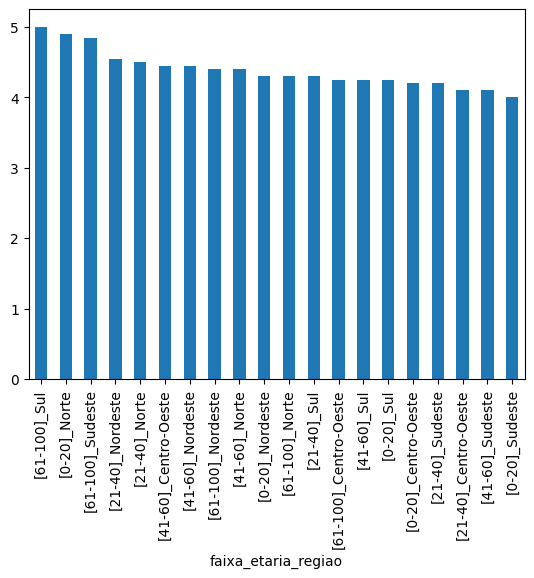

In [33]:
dataframe_aux3 = df.groupby(['faixa_etaria', 'customer_region'])['nps_score'].median().sort_values(ascending=False)
dataframe_aux3.index = dataframe_aux3.index.map(lambda x: f"{x[0]}_{x[1]}")
dataframe_aux3.index.name = 'faixa_etaria_regiao'
dataframe_aux3.plot(kind='bar', x='faixa_etaria_regiao', y='nps_score')

In [34]:
# sns.pairplot(df, hue='faixa_etaria')

In [35]:
# sns.pairplot(df, hue='customer_region')

In [36]:
df['customer_id'].duplicated().sum()

np.int64(0)

## Análise de dados de duas variáveis

## Análise de dados de três ou mais variáveis

In [37]:
# sns.pairplot(df, hue='customer_region')

# Analisar o Desconto

In [38]:
df[['order_value', 'discount_value']].head(10)

,order_value,discount_value
0,139.73,39.35
1,458.95,9.51
2,507.06,42.82
3,302.19,19.58
4,253.06,29.37
5,568.76,36.58
6,41.29,99.62
7,428.76,29.54
8,121.56,91.95
9,411.01,37.47


In [39]:
df['init_order_value'] = df['order_value'] + df['discount_value']
df['discount_percentage'] = (df['discount_value'] * 100 / df['init_order_value']).round(2)
df[['init_order_value', 'discount_value', 'order_value', 'discount_percentage']]

,init_order_value,discount_value,order_value,discount_percentage
0,179.08,39.35,139.73,21.97
1,468.46,9.51,458.95,2.03
2,549.88,42.82,507.06,7.79
3,321.77,19.58,302.19,6.09
4,282.43,29.37,253.06,10.40
...,...,...,...,...
2495,627.22,11.41,615.81,1.82
2496,109.47,36.44,73.03,33.29
2497,527.62,4.84,522.78,0.92
2498,57.98,2.11,55.87,3.64


In [40]:
df[['nps_score', 'discount_percentage']].corr()

,nps_score,discount_percentage
nps_score,1.00000,-0.01085
discount_percentage,-0.01085,1.00000


In [41]:
df['discount_percentage'].describe()

,discount_percentage
count,2500.000000
mean,8.945092
std,10.745727
min,0.000000
25%,2.050000
50%,5.410000
75%,11.390000
max,79.010000


In [42]:
df['discount_bucketized'] = pd.cut(df['discount_percentage'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80])
df['discount_bucketized'].value_counts()

,count
discount_bucketized,
"(0, 10]",1766
"(10, 20]",452
"(20, 30]",153
"(30, 40]",65
"(40, 50]",28
"(50, 60]",19
"(60, 70]",9
"(70, 80]",7


In [43]:
df[['init_order_value', 'discount_value', 'order_value', 'discount_percentage', 'discount_bucketized']].head(10)

,init_order_value,discount_value,order_value,discount_percentage,discount_bucketized
0,179.08,39.35,139.73,21.97,"(20, 30]"
1,468.46,9.51,458.95,2.03,"(0, 10]"
2,549.88,42.82,507.06,7.79,"(0, 10]"
3,321.77,19.58,302.19,6.09,"(0, 10]"
4,282.43,29.37,253.06,10.40,"(10, 20]"
5,605.34,36.58,568.76,6.04,"(0, 10]"
6,140.91,99.62,41.29,70.70,"(70, 80]"
7,458.30,29.54,428.76,6.45,"(0, 10]"
8,213.51,91.95,121.56,43.07,"(40, 50]"
9,448.48,37.47,411.01,8.35,"(0, 10]"


<Axes: xlabel='discount_bucketized'>

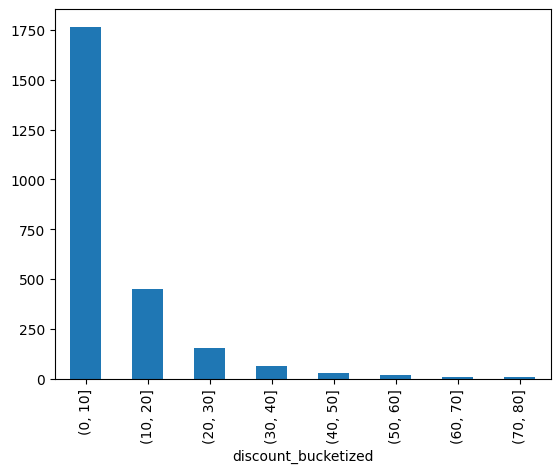

In [44]:
df['discount_bucketized'].value_counts().plot(kind='bar')

/tmp/ipykernel_2437/2287371095.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  nps_order = df.groupby('discount_bucketized')['nps_score'].mean().sort_values(ascending=False).index
/tmp/ipykernel_2437/2287371095.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df, y='nps_score', x='discount_bucketized', errorbar=None, palette='Reds', order=nps_order)


<Axes: xlabel='discount_bucketized', ylabel='nps_score'>

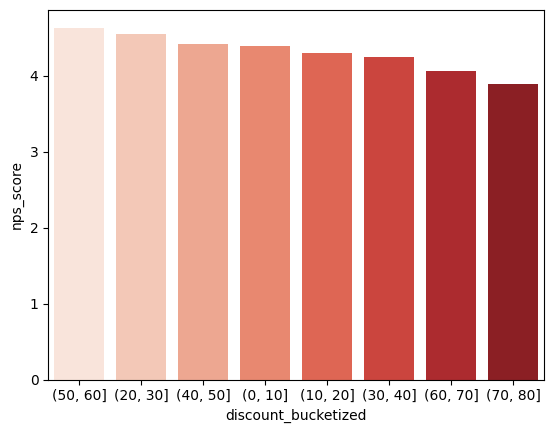

In [45]:
nps_order = df.groupby('discount_bucketized')['nps_score'].mean().sort_values(ascending=False).index
sns.barplot(df, y='nps_score', x='discount_bucketized', errorbar=None, palette='Reds', order=nps_order)

Aparentemente não há relação de nps com desconto.

# Segmentar Detratores

In [46]:
def classify_nps(score):
    if score >= 9:
        return 'promoter'
    if score >= 7:
        return 'passive'
    return 'detractor'

df['nps_class'] = df['nps_score'].map(classify_nps)
df[['nps_score', 'nps_class']]

,nps_score,nps_class
0,6.9,detractor
1,2.4,detractor
2,4.8,detractor
3,5.9,detractor
4,6.1,detractor
...,...,...
2495,3.7,detractor
2496,3.7,detractor
2497,7.4,passive
2498,2.3,detractor


<Axes: xlabel='nps_class'>

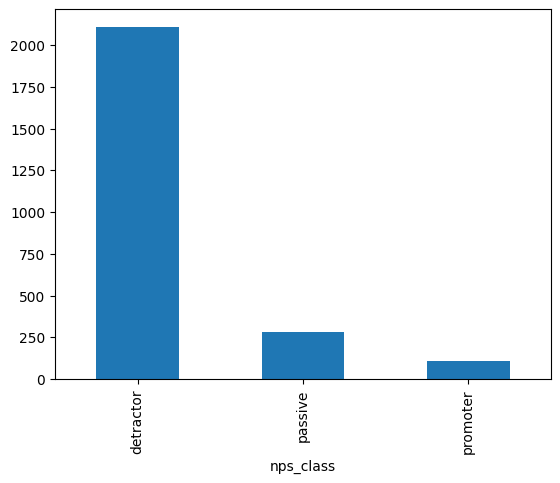

In [47]:
df['nps_class'].value_counts().plot(kind='bar')

In [48]:
df['nps_class'].value_counts()

,count
nps_class,
detractor,2109
passive,281
promoter,110


Claramente há muito mais detratores do que outros. Portanto, faz sentido pegar apenas os detratores e tentar entender o que levou o usuário a dar nota ruim, o que possuem em comum, em vez de tentar entender por que há poucos promotores+passivos ou que leva a dar nota alta (não será possível chegar numa boa conclusão com poucos registros de promotores+passivos).

In [49]:
df_detractors = df[df['nps_class'] == 'detractor']
df_detractors

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,...,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,faixa_etaria,init_order_value,discount_percentage,discount_bucketized,nps_class
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,...,4,6.9,0,3,6.5,[61-100],179.08,21.97,"(20, 30]",detractor
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,...,10,2.4,0,3,0.0,[0-20],468.46,2.03,"(0, 10]",detractor
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,...,5,4.8,0,7,1.5,[41-60],549.88,7.79,"(0, 10]",detractor
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,...,11,5.9,0,4,0.3,[41-60],321.77,6.09,"(0, 10]",detractor
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,...,0,6.1,0,3,7.9,[41-60],282.43,10.40,"(10, 20]",detractor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2492,2493,61,Centro-Oeste,52,52493,678.12,5,77.02,1,8,...,10,4.3,0,4,0.0,[61-100],755.14,10.20,"(10, 20]",detractor
2494,2495,66,Norte,91,52495,345.83,1,9.27,1,14,...,8,4.6,0,3,0.0,[61-100],355.10,2.61,"(0, 10]",detractor
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,...,2,3.7,0,3,4.3,[41-60],627.22,1.82,"(0, 10]",detractor
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,...,7,3.7,0,4,2.5,[21-40],109.47,33.29,"(30, 40]",detractor


In [50]:
df.corr(numeric_only=True)['nps_score'].sort_values(ascending=False)

,nps_score
nps_score,1.000000
repeat_purchase_30d,0.570324
csat_internal_score,0.563952
init_order_value,0.039277
order_value,0.036990
delivery_attempts,0.027680
discount_value,0.025104
payment_installments,0.023718
order_id,0.015162
customer_id,0.015162


In [51]:
df.corr(numeric_only=True)['customer_tenure_months'].sort_values(ascending=False)

,customer_tenure_months
customer_tenure_months,1.000000
customer_age,0.029889
customer_id,0.024351
order_id,0.024351
repeat_purchase_30d,0.024008
discount_value,0.015332
init_order_value,0.012972
order_value,0.011507
delivery_delay_days,0.001198
payment_installments,0.000205


In [52]:
df.corr(numeric_only=True)['complaints_count'].sort_values(ascending=False)

,complaints_count
complaints_count,1.000000
customer_service_contacts,0.754617
delivery_delay_days,0.190225
items_quantity,0.024986
freight_value,0.022673
resolution_time_days,0.018057
customer_age,0.008211
init_order_value,0.001961
order_value,0.001893
discount_value,0.000792


In [53]:
df_detractors.corr(numeric_only=True)['nps_score'].sort_values(ascending=False)

,nps_score
nps_score,1.000000
csat_internal_score,0.464380
items_quantity,0.026035
payment_installments,0.020499
init_order_value,0.017901
delivery_attempts,0.017264
order_value,0.016925
discount_value,0.011051
customer_id,0.001509
order_id,0.001509


In [54]:
df_detractors['repeat_purchase_30d'].value_counts()

,count
repeat_purchase_30d,
0,2109


> Gemini: O valor NaN na correlação entre nps_score e repeat_purchase_30d geralmente significa que uma das variáveis tem um valor constante (ou seja, não há variação) dentro do subconjunto de dados que você está correlacionando. Neste caso, é provável que todos os detratores tenham o mesmo valor para repeat_purchase_30d.


É possível verificar que nenhum detrator fez uma recompra.

In [55]:
df['repeat_purchase_30d'].value_counts()

,count
repeat_purchase_30d,
0,2282
1,218


In [56]:
df[df['repeat_purchase_30d'] > 0]['nps_class'].value_counts()

,count
nps_class,
promoter,110
passive,108


Acima é possível confirmar que os que fizeram alguma recompra são apenas promotores+passivos.

In [57]:
df_detractors.corr(numeric_only=True)['nps_score'].sort_values(ascending=False)

,nps_score
nps_score,1.000000
csat_internal_score,0.464380
items_quantity,0.026035
payment_installments,0.020499
init_order_value,0.017901
delivery_attempts,0.017264
order_value,0.016925
discount_value,0.011051
customer_id,0.001509
order_id,0.001509


Já que buscamos apenas as variáveis que podem explicar a queda do nps, podemos ver que **delivery_delay_days** e **complaints_count** são as que possuem maior correlação inversa ao valor do nps, ou seja, quanto maior esses valores piores são os nps.

Agora temos que confirmar e provar que essas são as causas da baixa no nps.

In [58]:
df_detractors['complaints_count'].value_counts()

,count
complaints_count,
4,539
5,420
3,414
6,259
2,181
7,164
8,63
1,37
9,16


<Axes: >

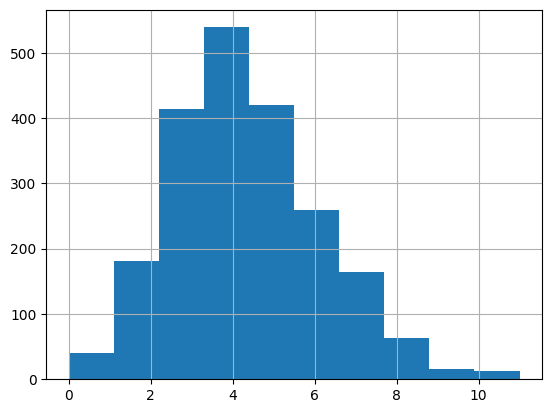

In [59]:
df_detractors['complaints_count'].hist()

/tmp/ipykernel_2437/2600507592.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_detractors, y='nps_score', x='complaints_count', errorbar=None, palette='Reds')


<Axes: xlabel='complaints_count', ylabel='nps_score'>

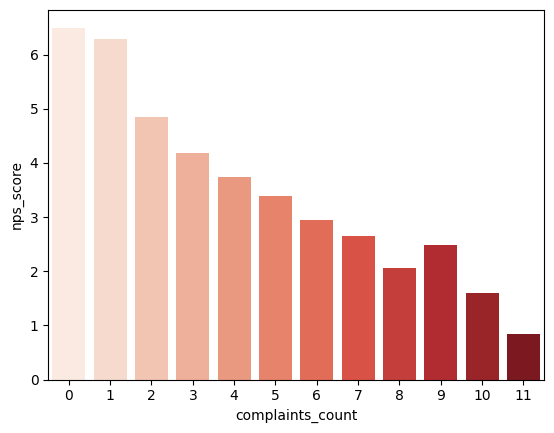

In [60]:
sns.barplot(df_detractors, y='nps_score', x='complaints_count', errorbar=None, palette='Reds')

Nesse gráfico podemos confirmar que há uma correlação (inversa) e muito provável causa.

### Quanto mais reclamações, pior o NPS. ✅
 **Insight**: é necessário melhorar o serviço do e-commerce para evitar reclamações.

## Analisar delivery_delay_days

In [61]:
df_detractors['delivery_delay_days'].value_counts()

,count
delivery_delay_days,
2,568
3,508
1,455
4,268
0,143
5,116
6,34
7,14
8,3


<Axes: >

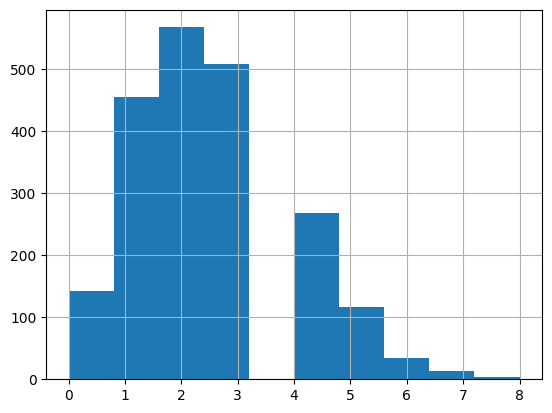

In [62]:
df_detractors['delivery_delay_days'].hist()

/tmp/ipykernel_2437/4020790110.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_detractors, y='nps_score', x='delivery_delay_days', errorbar=None, palette='Reds')


<Axes: xlabel='delivery_delay_days', ylabel='nps_score'>

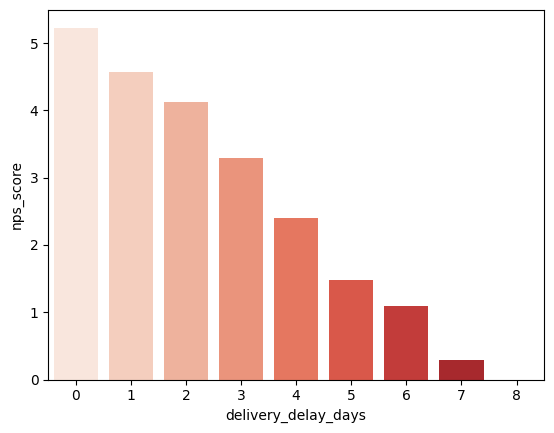

In [63]:
sns.barplot(df_detractors, y='nps_score', x='delivery_delay_days', errorbar=None, palette='Reds')

Aqui também confirmamos a correlação. ✅

**Insight**: com o aumento de demanda, tiveram problemas na logística, houve aumento de atraso na entrega, essas entregas atrasadas aumentaram o número de reclamações e os clientes deram nota baixa no nps.

## Será que dias de atraso tem relacao causal com quantidade de reclamções?

/tmp/ipykernel_2437/4253996541.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_detractors, y='complaints_count', x='delivery_delay_days', errorbar=None, palette='Reds')


<Axes: xlabel='delivery_delay_days', ylabel='complaints_count'>

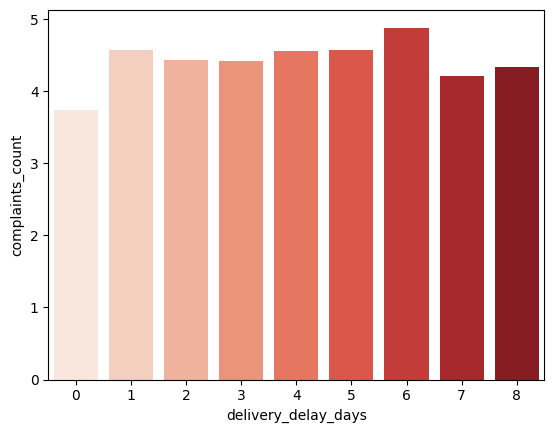

In [64]:
sns.barplot(df_detractors, y='complaints_count', x='delivery_delay_days', errorbar=None, palette='Reds')

In [65]:
df_detractors.corr(numeric_only=True)['delivery_delay_days'].sort_values(ascending=False)

,delivery_delay_days
delivery_delay_days,1.000000
complaints_count,0.055939
order_value,0.021437
init_order_value,0.016788
delivery_attempts,0.010879
freight_value,0.008208
delivery_time_days,-0.001501
customer_age,-0.002217
customer_tenure_months,-0.002338
order_id,-0.009555


In [66]:
df['csat_internal_score'].isnull().sum()

np.int64(0)

In [67]:
df['customer_service_contacts'].value_counts()

,count
customer_service_contacts,
1,816
2,640
0,554
3,314
4,132
5,34
6,7
7,3


In [68]:
df['customer_service_contacts'].head()

,customer_service_contacts
0,0
1,0
2,4
3,1
4,1


<Axes: >

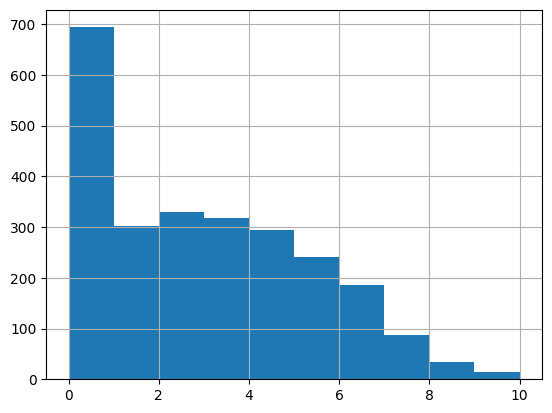

In [69]:
df['csat_internal_score'].hist()

In [87]:
# 2. Escala de 0 a 10
# Nesse modelo, o cliente avalia a experiência pontual:
# Notas 9 e 10: Muito Satisfeito / Excelente.
# Notas 7 e 8: Satisfeito / Bom.
# Notas abaixo de 7: Neutro a Insatisfeito.

def classify_csat(score):
    if score >= 9:
        return 'very_satisfied'
    if score >= 7:
        return 'satisfied'
    return 'unsatisfied'

df['csat_class'] = df['csat_internal_score'].map(classify_csat)
df[['csat_internal_score', 'csat_class']]

,csat_internal_score,csat_class
0,6.5,unsatisfied
1,0.0,unsatisfied
2,1.5,unsatisfied
3,0.3,unsatisfied
4,7.9,satisfied
...,...,...
2495,4.3,unsatisfied
2496,2.5,unsatisfied
2497,6.2,unsatisfied
2498,1.7,unsatisfied


<Axes: xlabel='csat_class'>

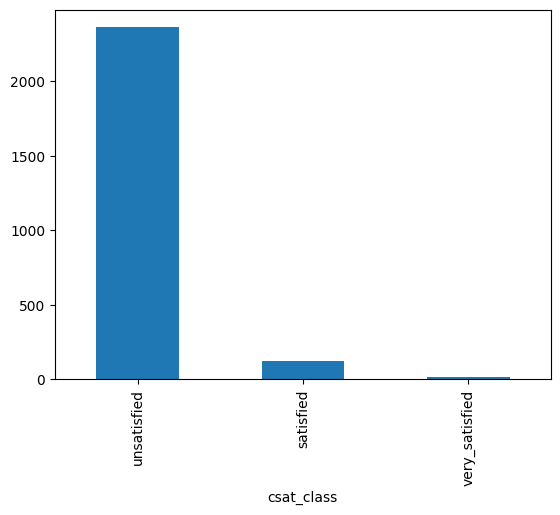

In [71]:
df['csat_class'].value_counts().plot(kind='bar')

In [72]:
df[['csat_class', 'nps_class']].value_counts()

csat_class      nps_class
unsatisfied     detractor    2051
                passive       241
                promoter       71
satisfied       detractor      58
                passive        35
                promoter       30
very_satisfied  promoter        9
                passive         5
Name: count, dtype: int64

In [73]:
df.corr(numeric_only=True)['csat_internal_score'].sort_values(ascending=False)

,csat_internal_score
csat_internal_score,1.000000
nps_score,0.563952
repeat_purchase_30d,0.342653
discount_value,0.040063
discount_percentage,0.022204
customer_id,0.007807
order_id,0.007807
init_order_value,0.004818
payment_installments,0.001777
order_value,0.000807


In [74]:
df.corr(numeric_only=True)['resolution_time_days'].sort_values(ascending=False)

,resolution_time_days
resolution_time_days,1.000000
delivery_time_days,0.021217
complaints_count,0.018057
items_quantity,0.017519
payment_installments,0.015277
delivery_attempts,0.014928
customer_service_contacts,0.014678
customer_age,0.005458
customer_id,-0.000063
order_id,-0.000063


/tmp/ipykernel_2437/4185989661.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_detractors, y='csat_internal_score', x='nps_score', errorbar=None, palette='Reds')


<Axes: xlabel='nps_score', ylabel='csat_internal_score'>

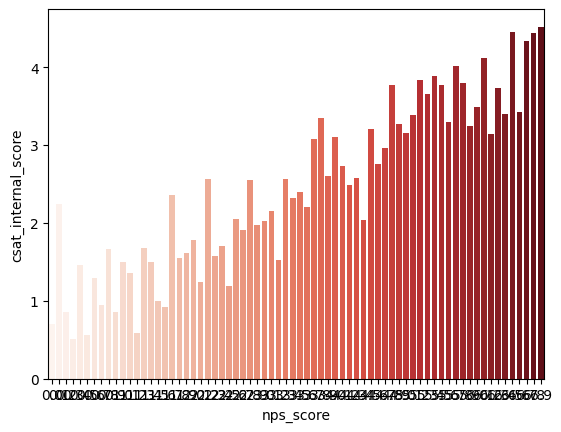

In [75]:
sns.barplot(df_detractors, y='csat_internal_score', x='nps_score', errorbar=None, palette='Reds')

In [76]:
df['customer_tenure_months'].value_counts()

,count
customer_tenure_months,
80,38
95,34
108,31
26,30
11,30
...,...
36,14
54,13
38,13


In [77]:
df['customer_tenure_months'].max()

119

In [78]:
df['tenure_bucketized'] = pd.cut(df['customer_tenure_months'], bins=[0, 20, 40, 60, 80, 100, 120]).value_counts()

In [80]:
df[df['customer_tenure_months'] >= 100].corr(numeric_only=True)['nps_score'].sort_values(ascending=False)

,nps_score
nps_score,1.000000
repeat_purchase_30d,0.592947
csat_internal_score,0.580552
tenure_bucketized,0.137961
customer_tenure_months,0.062562
delivery_time_days,0.047977
delivery_attempts,0.023952
order_value,0.012304
init_order_value,0.010302
payment_installments,-0.004213


In [81]:
df_detractors[df_detractors['customer_tenure_months'] >= 100].corr(numeric_only=True)['nps_score'].sort_values(ascending=False)

,nps_score
nps_score,1.000000
csat_internal_score,0.471203
customer_tenure_months,0.052184
order_value,0.015848
init_order_value,0.010683
payment_installments,0.008168
customer_id,-0.004085
order_id,-0.004085
delivery_time_days,-0.004920
items_quantity,-0.010383


In [82]:
df[df['csat_internal_score'] <= 1]['nps_score']

,nps_score
1,2.4
3,5.9
6,1.4
8,6.2
12,3.7
...,...
2468,1.8
2484,1.6
2486,0.8
2492,4.3


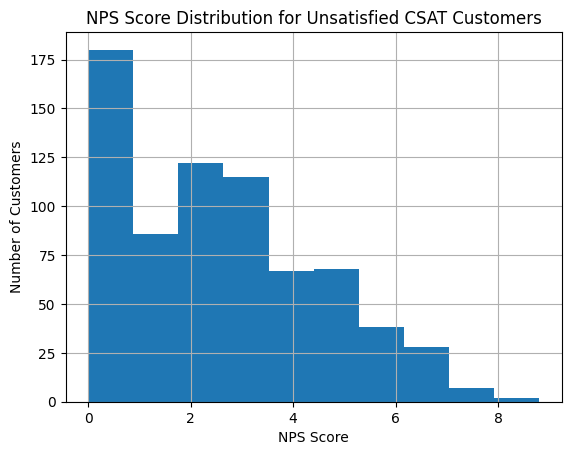

In [88]:
df_unsatisfied_csat = df[df['csat_internal_score'] <= 1]
df_unsatisfied_csat['nps_score'].hist(bins=10)
plt.title('NPS Score Distribution for Unsatisfied CSAT Customers')
plt.xlabel('NPS Score')
plt.ylabel('Number of Customers')
plt.show()

# Seleção dos gráficos que achei mais relevantes

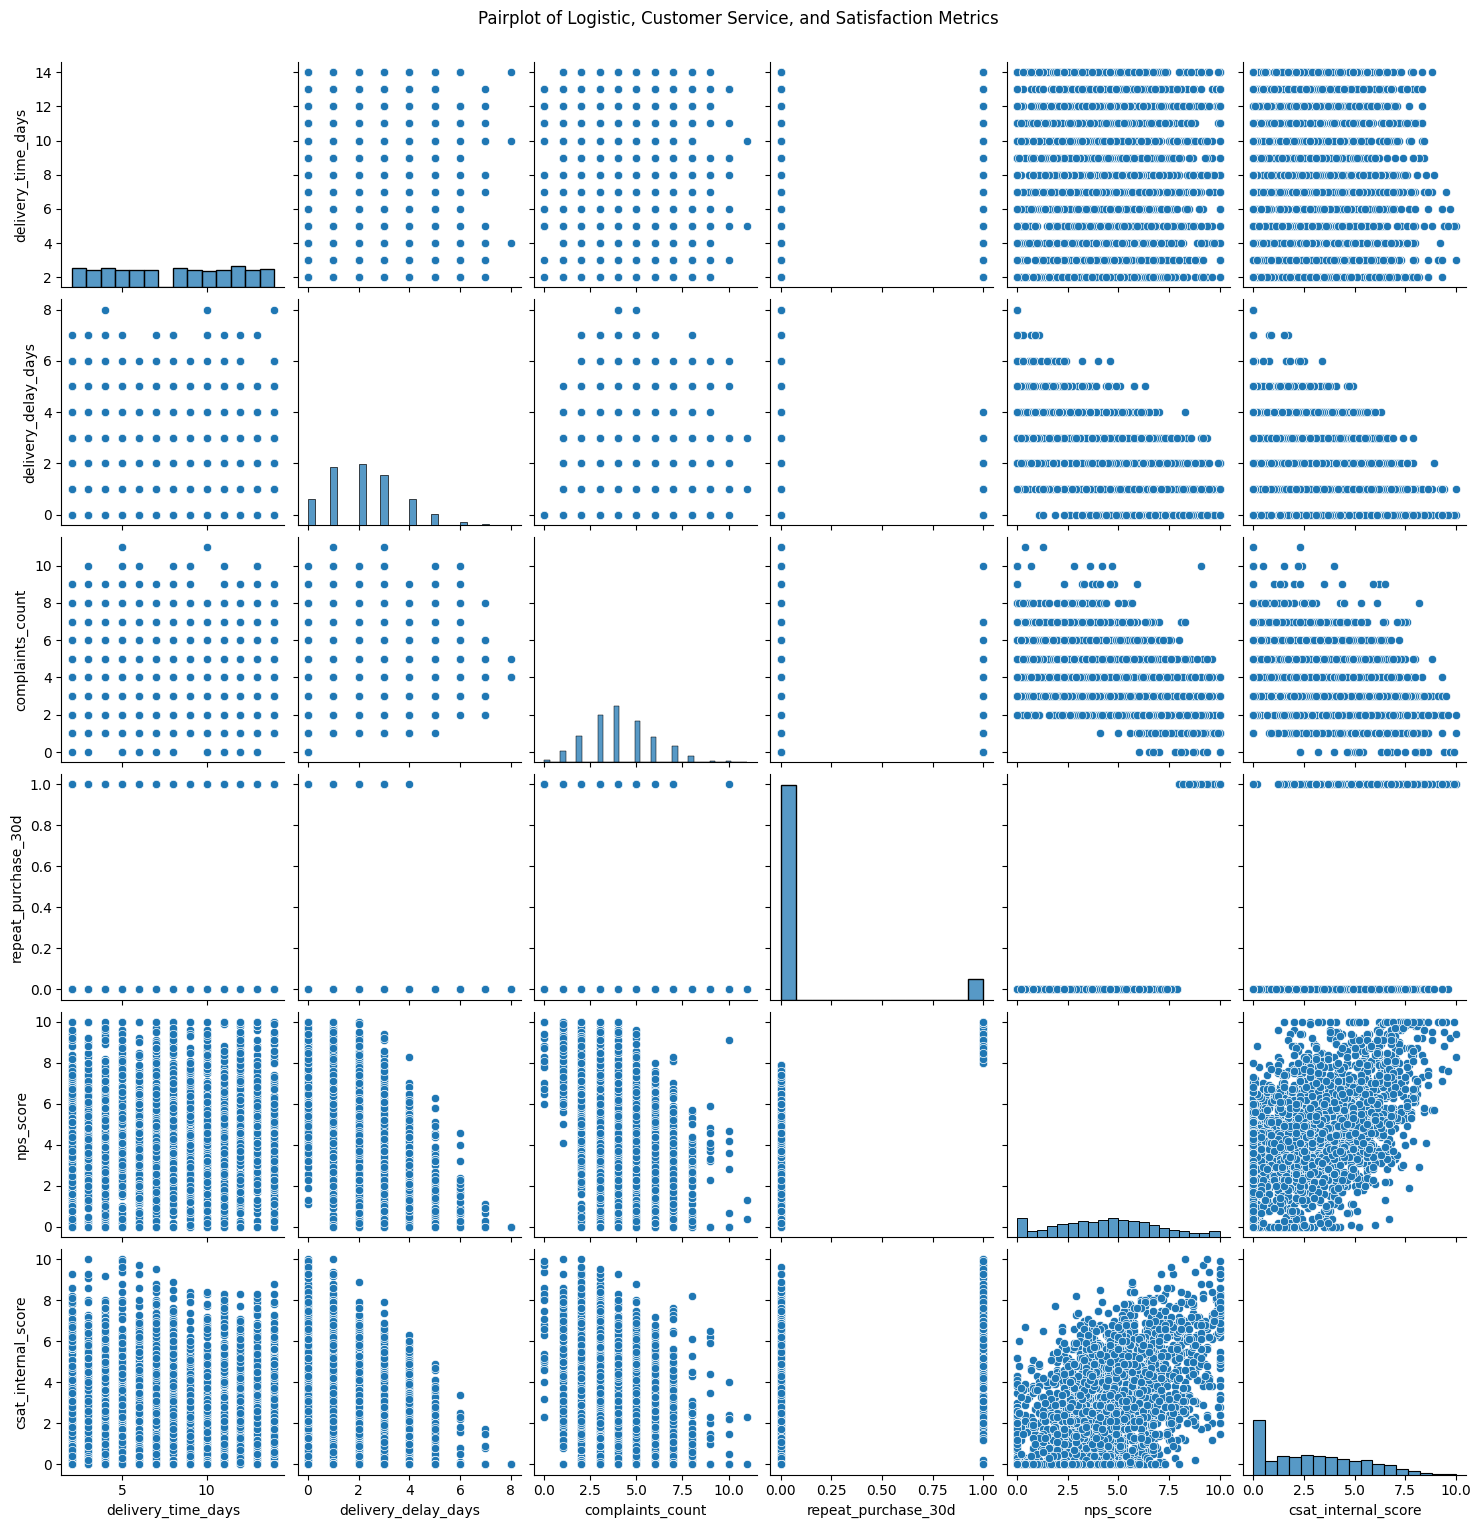

In [113]:
columns_for_pairplot = [
    'delivery_time_days',
    'delivery_delay_days',
    'complaints_count',
    'repeat_purchase_30d',
    'nps_score',
    'csat_internal_score'
]
sns.pairplot(df, vars=columns_for_pairplot)
plt.suptitle('Pairplot of Logistic, Customer Service, and Satisfaction Metrics', y=1.02)
plt.show()

/tmp/ipykernel_2437/4020790110.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_detractors, y='nps_score', x='delivery_delay_days', errorbar=None, palette='Reds')


<Axes: xlabel='delivery_delay_days', ylabel='nps_score'>

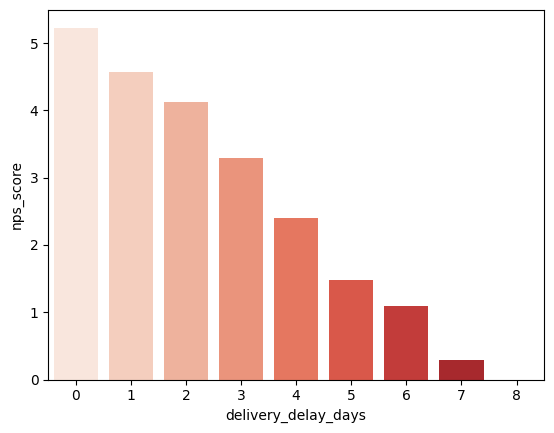

In [110]:
sns.barplot(df_detractors, y='nps_score', x='delivery_delay_days', errorbar=None, palette='Reds')

Percebe-se que quanto maior o atraso, menor a chance de uma nota alta do NPS. Porém mesmo com pouco atraso, ainda existe nota baixa, o que nos leva a entender que existe mais fatores que provocam a nota baixa do NPS.

/tmp/ipykernel_2437/2600507592.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_detractors, y='nps_score', x='complaints_count', errorbar=None, palette='Reds')


<Axes: xlabel='complaints_count', ylabel='nps_score'>

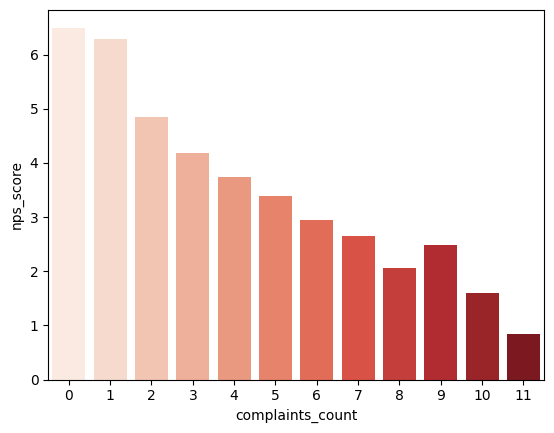

In [111]:
sns.barplot(df_detractors, y='nps_score', x='complaints_count', errorbar=None, palette='Reds')

Nesse gráfico podemos confirmar que há uma correlação (inversa) e muito provável causa.

Quanto mais reclamações, pior o NPS. ✅

Insight: é necessário melhorar o serviço do e-commerce para evitar reclamações.

## Análise de contatos com o serviço de atendimento ao cliente (para detratores)

customer_service_contacts
1    685
2    567
0    392
3    293
4    129
5     33
6      7
7      3
Name: count, dtype: int64


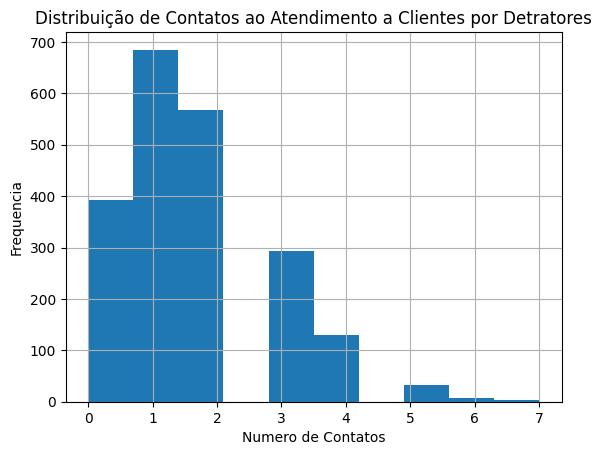

In [108]:
print(df_detractors['customer_service_contacts'].value_counts())
df_detractors['customer_service_contacts'].hist()
plt.title('Distribuição de Contatos ao Atendimento a Clientes por Detratores')
plt.xlabel('Numero de Contatos')
plt.ylabel('Frequencia')
plt.show()

/tmp/ipykernel_2437/629465330.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_detractors, y='nps_score', x='customer_service_contacts', errorbar=None, palette='Reds')


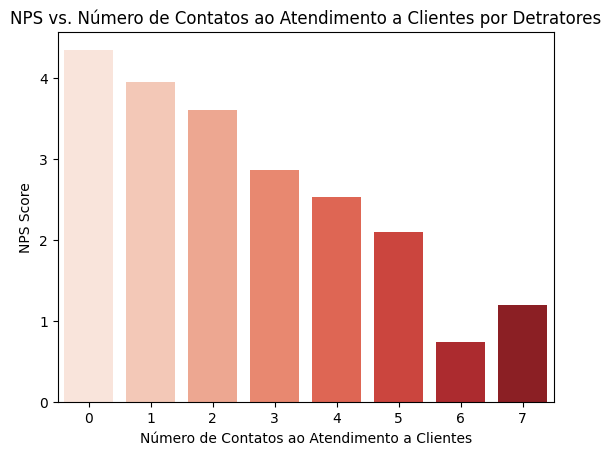

In [107]:
sns.barplot(df_detractors, y='nps_score', x='customer_service_contacts', errorbar=None, palette='Reds')
plt.title('NPS vs. Número de Contatos ao Atendimento a Clientes por Detratores')
plt.xlabel('Número de Contatos ao Atendimento a Clientes')
plt.ylabel('NPS Score')
plt.show()

Aqui podemos observar uma clara tendência: quanto maior o número de contatos com o serviço de atendimento ao cliente, menor o NPS. Isso sugere que a necessidade de múltiplos contatos para resolver problemas é um forte indicador de insatisfação.

Insight: É crucial otimizar a eficiência do atendimento ao cliente para resolver problemas no primeiro contato, reduzindo a necessidade de recontatos e melhorando a experiencia.

## Análise do tempo de resolução de problemas (para detratores)

resolution_time_days
8     202
11    195
2     187
3     185
7     183
10    181
9     180
4     175
6     168
0     156
5     151
1     146
Name: count, dtype: int64


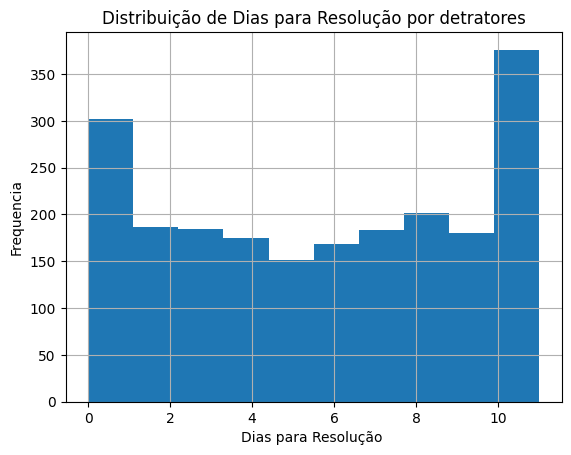

In [106]:
print(df_detractors['resolution_time_days'].value_counts())
df_detractors['resolution_time_days'].hist()
plt.title('Distribuição de Dias para Resolução por detratores')
plt.xlabel('Dias para Resolução ')
plt.ylabel('Frequencia')
plt.show()

/tmp/ipykernel_2437/4099446854.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df_detractors, y='nps_score', x='resolution_time_days', errorbar=None, palette='Reds')


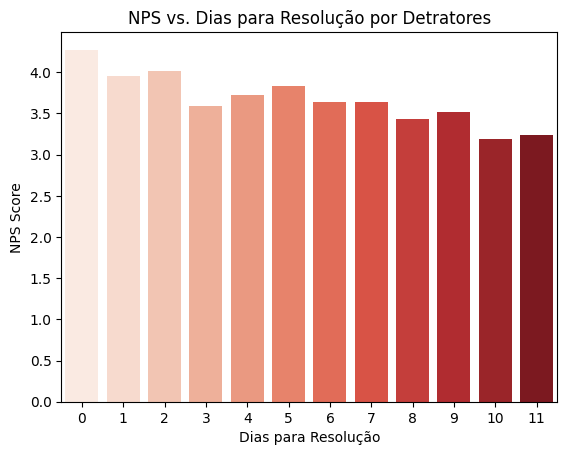

In [104]:
sns.barplot(df_detractors, y='nps_score', x='resolution_time_days', errorbar=None, palette='Reds')
plt.title('NPS vs. Dias para Resolução por Detratores')
plt.xlabel('Dias para Resolução')
plt.ylabel('NPS Score')
plt.show()

Assim como nos contatos com o atendimento, o tempo de resolução também impacta negativamente o NPS. Quanto maior o tempo para resolver um problema, menor o NPS.

Insight: A agilidade na resolução de problemas é um fator crítico para a satisfação do cliente e, consequentemente, para o NPS. Reduzir o tempo de resolução pode ser uma estratégia eficaz para melhorar a experiência do cliente.

<Axes: xlabel='faixa_etaria_regiao'>

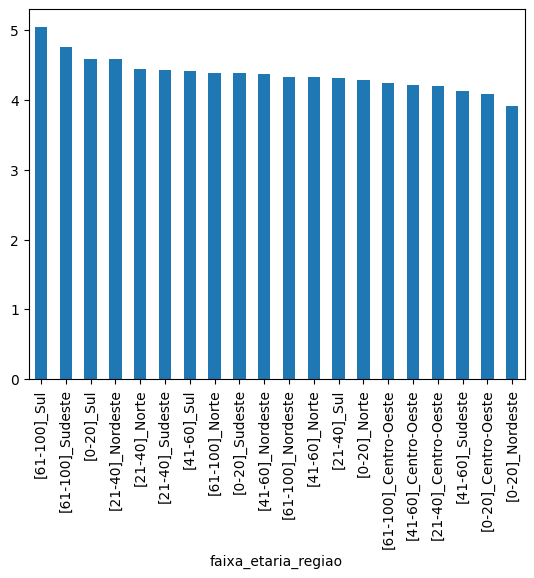

In [32]:

dataframe_aux2.plot(kind='bar', x='faixa_etaria_regiao', y='nps_score')

Embora não haja uma correlação forte com a idade, clientes das regiões Sul e Nordeste, especialmente os mais velhos, tendem a apresentar pontuações médias de NPS mais altas.